# Notes
To understand cross-validation from first principles, we must strip away all machine learning jargon and start with a fundamental truth about human learning, logic, and prediction.
Here is the step-by-step first-principles breakdown of why cross-validation must exist.


------------------------------
## Phase 1: The First Principle of Learning

Principle 1: Memorization is not the same as understanding.

Imagine you are studying for a history exam.

* Scenario A: Your teacher gives you a practice test with 10 questions. You study only those 10 questions and memorize the exact answers. On exam day, the teacher gives you the exact same 10 questions. You score 100%. Are you a history genius? No. You just have a good memory.
* Scenario B: You study those 10 questions. On exam day, the teacher gives you 10 completely new questions about the same historical era. If you score 100% now, you have proven you actually understand the underlying patterns of history.

In machine learning, a model is nothing more than a math equation trying to find patterns. If you train it on a dataset and then test it on that same dataset, it will simply memorize the noise and specifics of that data (Overfitting). [1, 2, 3] 
Conclusion 1: To know if a model actually understands, you must test it on data it has never seen before. This introduces the traditional split: Train Set (to learn) and Test Set (to grade).


------------------------------
## Phase 2: The Limitation of a Single Split
Now, let's look at the next limitation. Data is scarce, expensive, and finite.  

Principle 2: A single, static snapshot of reality can be deceptive or lucky.

Imagine you split your limited dataset of 100 patients into 80 for training and 20 for testing.

* What if, purely by random chance, the 20 patients in your test set happen to be the easiest, healthiest, or most obvious cases? Your model scores 100% on the test. You think your model is perfect.
* What if those 20 patients happen to be highly unusual, rare anomaly cases? Your model scores 30%. You throw your model away, thinking it is terrible.

In both scenarios, your grade is wrong. It was dictated by a lucky or unlucky split, not by the actual quality of your model. 
Conclusion 2: A single train/test split introduces massive variance and uncertainty. You cannot trust a one-time test.  
------------------------------
## Phase 3: The First-Principles Solution (Cross-Validation)
How do you solve the need for a final exam (Phase 1) while avoiding the luck of a single split (Phase 2), all while using the same limited pool of data?

Principle 3: If a pattern is truly universal, it must hold true no matter which part of the data you hide.

Instead of picking one static test set, you make every piece of data take a turn being the test set. [15] 
Let's say you have 5 boxes of data.

   1. Round 1: Hide Box 1. Learn from Boxes 2, 3, 4, 5. Test your knowledge on Box 1. (Get Score 1)
   2. Round 2: Hide Box 2. Learn from Boxes 1, 3, 4, 5. Test your knowledge on Box 2. (Get Score 2)
   3. Round 3: Hide Box 3. Learn from Boxes 1, 2, 4, 5. Test your knowledge on Box 3. (Get Score 3)
   4. Repeat until every box has been hidden exactly once.

Finally, you average the scores from all rounds. [16] 
------------------------------
## The Mathematical Elegance of this Solution
By enforcing this systematic rotation, you achieve three things simultaneously from a pure logical standpoint:

* Zero Waste: 100% of your data gets used to train the model across the rounds.
* Honest Grading: 100% of your data gets used as an unseen "final exam" exactly once.
* Smoothed Luck: If Round 1 had a "lucky" test split, Round 2 will likely balance it out with a tougher one. The average of all rounds provides a highly stable, true reflection of reality. 

## Summary: Cross-Validation taught in one sentence
Cross-validation is the logical mechanism of simulating multiple future unseen datasets by systematically shifting what is "known" and "unknown" within your current limited data. [18, 19] 
To continue building your foundations, where should we go next? We can look at how this changes when data has a time element (like stocks), or we can look at how many folds (k) you should logically choose. 


# Hold out approach

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


In [9]:
X = fetch_california_housing(as_frame=True)['data']
y = fetch_california_housing(as_frame=True)['target']

In [10]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [11]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [14]:
# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

This is our hold out approach . which do train test split 

In [15]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Use the trained model to predict the target values in the test set
y_pred = model.predict(X_test)

# Calculate the Mean Squared Error of the model on the test set
mse = mean_squared_error(y_test, y_pred)

print('Mean Squared Error:', mse)

r2 = r2_score(y_test, y_pred)

print('r2 score:', r2)

Mean Squared Error: 0.5369436868087002
r2 score: 0.6013853272055154


In [18]:
def hold_out_approach(our_random_state): 
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=our_random_state)
    
    # Create a linear regression model
    model = LinearRegression()

    # Train the model on the training data
    model.fit(X_train, y_train)

    # Use the trained model to predict the target values in the test set
    y_pred = model.predict(X_test)

    # Calculate the Mean Squared Error of the model on the test set
    mse = mean_squared_error(y_test, y_pred)

    print('Mean Squared Error:', mse)

    r2 = r2_score(y_test, y_pred)

    print('r2 score:', r2)
    
hold_out_approach(1)

Mean Squared Error: 0.5291402345397309
r2 score: 0.5965968374812353


In [19]:
hold_out_approach(2)

Mean Squared Error: 0.5369436868087002
r2 score: 0.6013853272055154


In [20]:
hold_out_approach(3)

Mean Squared Error: 0.5381050871563083
r2 score: 0.5931493041831686


In [21]:
hold_out_approach(100)

Mean Squared Error: 0.5088933351158942
r2 score: 0.6223138107295292


Observation : jesa aap random state ko badal raha ho model ko performance mse ,r2 score  change ho raha ha jo reliable nahi . 

# Cross Validation 

## LOOCV

In [42]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression  # Fix 1: Added missing import
from sklearn.model_selection import LeaveOneOut, cross_val_score

# Regression Datasets
diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target

# Create a linear regression model
Linear_reg_model = LinearRegression()

# Leave one out
loocv = LeaveOneOut()

# Fix 2: Changed 'mse' to 'neg_mean_squared_error'
neg_mse_scores = cross_val_score(
    Linear_reg_model, X, y, cv=loocv, scoring="neg_mean_squared_error"
)

# Fix 3: Convert negative MSE back to positive values
mse_scores = -neg_mse_scores
mean_loocv_mse = mse_scores.mean()

print(f"Mean LOOCV Mean Squared Error (MSE): {mean_loocv_mse:.4f}")
print(f"LOOCV Root Mean Squared Error (RMSE): {np.sqrt(mean_loocv_mse):.4f}")


Mean LOOCV Mean Squared Error (MSE): 3001.7528
LOOCV Root Mean Squared Error (RMSE): 54.7883


Apply the logistic regression on iris dataset 

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression

# 1. Load a perfect small dataset Classification
iris = load_iris()
X, y = iris.data, iris.target

# 2. Initialize LOOCV and Model
loocv = LeaveOneOut()
model = LogisticRegression(max_iter=200)

# 3. Evaluate
scores = cross_val_score(model, X, y, cv=loocv)

print(f"Total training iterations: {len(scores)}")
print(f"Mean LOOCV Accuracy: {scores.mean():.4f}")


Total training iterations: 150
Mean LOOCV Accuracy: 0.9667


## K fold

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

# 1. Load the dataset
california = fetch_california_housing(as_frame=True)
X, y = california.data, california.target

# 2. Define the K-Fold strategy
# 5-fold or 10-fold are the standard options. 
# shuffle=True mixes rows before splitting to break up geographic ordering.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Initialize the model
model = LinearRegression()

# 4. Evaluate using R² Score (Higher is better)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

# 5. Evaluate using Negative Mean Squared Error (Lower is better)
neg_mse_scores = cross_val_score(
    model, X, y, cv=kf, scoring="neg_mean_squared_error"
)
mse_scores = -neg_mse_scores  # Convert to positive MSE

# 6. Print Summary Metrics
print("======= 10-FOLD CROSS-VALIDATION RESULTS =======")
print(f"R² Scores per fold:  {r2_scores}")
print(f"Mean R² Score:       {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")
print("-" * 47)
print(f"MSE Scores per fold: {mse_scores}")
print(f"Mean MSE Score:      {mse_scores.mean():.4f} (± {mse_scores.std():.4f})")
print(f"Mean RMSE Score:     {np.sqrt(mse_scores.mean()):.4f}")


======= 5-FOLD CROSS-VALIDATION RESULTS =======
R² Scores per fold:  [0.57578771 0.61374822 0.60856043 0.62126494 0.5875292 ]
Mean R² Score:       0.6014 (± 0.0170)
-----------------------------------------------
MSE Scores per fold: [0.5558916  0.52765625 0.50928321 0.50485078 0.55518048]
Mean MSE Score:      0.5306 (± 0.0218)
Mean RMSE Score:     0.7284


In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

# 1. Load the dataset
california = fetch_california_housing(as_frame=True)
X, y = california.data, california.target

# 2. Define the K-Fold strategy
# 5-fold or 10-fold are the standard options. 
# shuffle=True mixes rows before splitting to break up geographic ordering.
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 3. Initialize the model
model = LinearRegression()

# 4. Evaluate using R² Score (Higher is better)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

# 5. Evaluate using Negative Mean Squared Error (Lower is better)
neg_mse_scores = cross_val_score(
    model, X, y, cv=kf, scoring="neg_mean_squared_error"
)
mse_scores = -neg_mse_scores  # Convert to positive MSE

# 6. Print Summary Metrics
print("======= 10-FOLD CROSS-VALIDATION RESULTS =======")
print(f"R² Scores per fold:  {r2_scores}")
print(f"Mean R² Score:       {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")
print("-" * 47)
print(f"MSE Scores per fold: {mse_scores}")
print(f"Mean MSE Score:      {mse_scores.mean():.4f} (± {mse_scores.std():.4f})")
print(f"Mean RMSE Score:     {np.sqrt(mse_scores.mean()):.4f}")


======= 10-FOLD CROSS-VALIDATION RESULTS =======
R² Scores per fold:  [0.58083533 0.57017917 0.6343602  0.5945333  0.6156131  0.60268638
 0.59072937 0.63988315 0.57780603 0.5941262 ]
Mean R² Score:       0.6001 (± 0.0222)
-----------------------------------------------
MSE Scores per fold: [0.55900192 0.5531233  0.48116128 0.57420367 0.48897584 0.52838818
 0.55117824 0.47483961 0.56436922 0.55002537]
Mean MSE Score:      0.5325 (± 0.0352)
Mean RMSE Score:     0.7297


## Stratified k fold

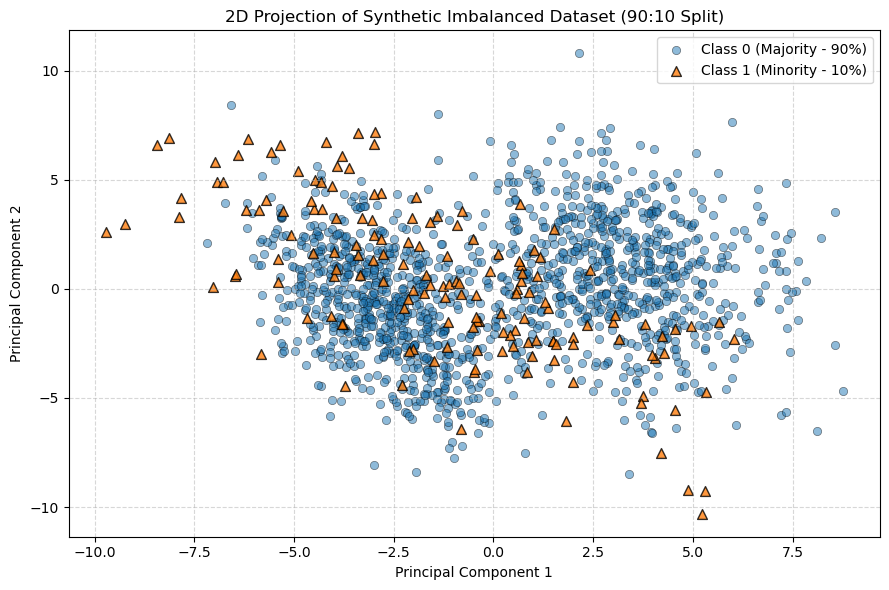

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA

# 1. Recreate the exact 90:10 imbalanced synthetic dataset
X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=8,
    weights=[0.9, 0.1],  # 90:10 Split
    random_state=42,
)

# 2. Reduce the 10 features down to 2 dimensions using PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

# 3. Separate the components based on the target class labels
class_0 = X_2d[y == 0]
class_1 = X_2d[y == 1]

# 4. Plot the data points
plt.figure(figsize=(9, 6))

# Plot Class 0 (90% - Majority)
plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    alpha=0.5,
    c="#1f77b4",
    label="Class 0 (Majority - 90%)",
    edgecolors="k",
    linewidths=0.5,
)

# Plot Class 1 (10% - Minority)
plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    alpha=0.8,
    c="#ff7f0e",
    marker="^",
    s=50,
    label="Class 1 (Minority - 10%)",
    edgecolors="k",
)

# 5. Format and present the visual chart
plt.title("2D Projection of Synthetic Imbalanced Dataset (90:10 Split)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Display plot
plt.show()


In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

# 1. Create the Synthetic Imbalanced Dataset (90% Class 0, 10% Class 1)
X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=8,
    weights=[0.9, 0.1],  # 90:10 Split
    random_state=42,
)

# Verify the imbalance ratio
labels, counts = np.unique(y, return_counts=True)
print("=== Dataset Profile ===")
print(f"Class 0 (Majority): {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
print(f"Class 1 (Minority): {counts[1]} ({counts[1]/len(y)*100:.1f}%)")
print("-" * 50)

# 2. Initialize Model and CV Strategies
# 'class_weight="balanced"' helps the logistic regression adapt to the 90:10 split
model = LogisticRegression(class_weight="balanced", random_state=42)

# Use 5 splits and the same random state to keep comparisons fair
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Apply Standard K-Fold Cross-Validation
kf_roc = cross_val_score(model, X, y, cv=kf, scoring="roc_auc")
kf_bal_acc = cross_val_score(model, X, y, cv=kf, scoring="balanced_accuracy")

# 4. Apply Stratified K-Fold Cross-Validation
skf_roc = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
skf_bal_acc = cross_val_score(model, X, y, cv=skf, scoring="balanced_accuracy")

# 5. Compare and Display Results
results = pd.DataFrame(
    {
        "Metric": [
            "Mean ROC-AUC Score",
            "ROC-AUC Std Dev (Variance)",
            "Mean Balanced Accuracy",
            "Balanced Acc Std Dev",
        ],
        "Normal K-Fold": [
            f"{kf_roc.mean():.4f}",
            f"{kf_roc.std():.4f}",
            f"{kf_bal_acc.mean():.4f}",
            f"{kf_bal_acc.std():.4f}",
        ],
        "Stratified K-Fold": [
            f"{skf_roc.mean():.4f}",
            f"{skf_roc.std():.4f}",
            f"{skf_bal_acc.mean():.4f}",
            f"{skf_bal_acc.std():.4f}",
        ],
    }
)

print(results.to_string(index=False))


=== Dataset Profile ===
Class 0 (Majority): 1345 (89.7%)
Class 1 (Minority): 155 (10.3%)
--------------------------------------------------
                    Metric Normal K-Fold Stratified K-Fold
        Mean ROC-AUC Score        0.7733            0.7712
ROC-AUC Std Dev (Variance)        0.0315            0.0417
    Mean Balanced Accuracy        0.7184            0.7140
      Balanced Acc Std Dev        0.0315            0.0174


In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

# 1. Create the  Higly Synthetic Imbalanced Dataset (90% Class 0, 10% Class 1)
X, y = make_classification(
    n_samples=1500,
    n_features=10,
    n_informative=8,
    weights=[0.995, 0.005],  # 90:10 Split
    random_state=42,
)

# Verify the imbalance ratio
labels, counts = np.unique(y, return_counts=True)
print("=== Dataset Profile ===")
print(f"Class 0 (Majority): {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
print(f"Class 1 (Minority): {counts[1]} ({counts[1]/len(y)*100:.1f}%)")
print("-" * 50)

# 2. Initialize Model and CV Strategies
# 'class_weight="balanced"' helps the logistic regression adapt to the 90:10 split
model = LogisticRegression(class_weight="balanced", random_state=42)

# Use 5 splits and the same random state to keep comparisons fair
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Apply Standard K-Fold Cross-Validation
kf_roc = cross_val_score(model, X, y, cv=kf, scoring="roc_auc")
kf_bal_acc = cross_val_score(model, X, y, cv=kf, scoring="balanced_accuracy")

# 4. Apply Stratified K-Fold Cross-Validation
skf_roc = cross_val_score(model, X, y, cv=skf, scoring="roc_auc")
skf_bal_acc = cross_val_score(model, X, y, cv=skf, scoring="balanced_accuracy")

# 5. Compare and Display Results
results = pd.DataFrame(
    {
        "Metric": [
            "Mean ROC-AUC Score",
            "ROC-AUC Std Dev (Variance)",
            "Mean Balanced Accuracy",
            "Balanced Acc Std Dev",
        ],
        "Normal K-Fold": [
            f"{kf_roc.mean():.4f}",
            f"{kf_roc.std():.4f}",
            f"{kf_bal_acc.mean():.4f}",
            f"{kf_bal_acc.std():.4f}",
        ],
        "Stratified K-Fold": [
            f"{skf_roc.mean():.4f}",
            f"{skf_roc.std():.4f}",
            f"{skf_bal_acc.mean():.4f}",
            f"{skf_bal_acc.std():.4f}",
        ],
    }
)

#print(results.to_string(index=False))
results


=== Dataset Profile ===
Class 0 (Majority): 1486 (99.1%)
Class 1 (Minority): 14 (0.9%)
--------------------------------------------------


,Metric,Normal K-Fold,Stratified K-Fold
0,Mean ROC-AUC Score,0.6793,0.6181
1,ROC-AUC Std Dev (Variance),0.2155,0.1098
2,Mean Balanced Accuracy,0.6268,0.5291
3,Balanced Acc Std Dev,0.1836,0.1481


# Varience comparions 
hold out approach vs k fold 

## single train test split 

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import seaborn as sns
df = sns.load_dataset('mpg')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


mpg is a good dataset to study the polynomial regression 

We apply the polynomial regression of differnet degree and calculate the mean sqaured error .       
so x axis = degree of freedom of polynomial                 
and y axis = mse

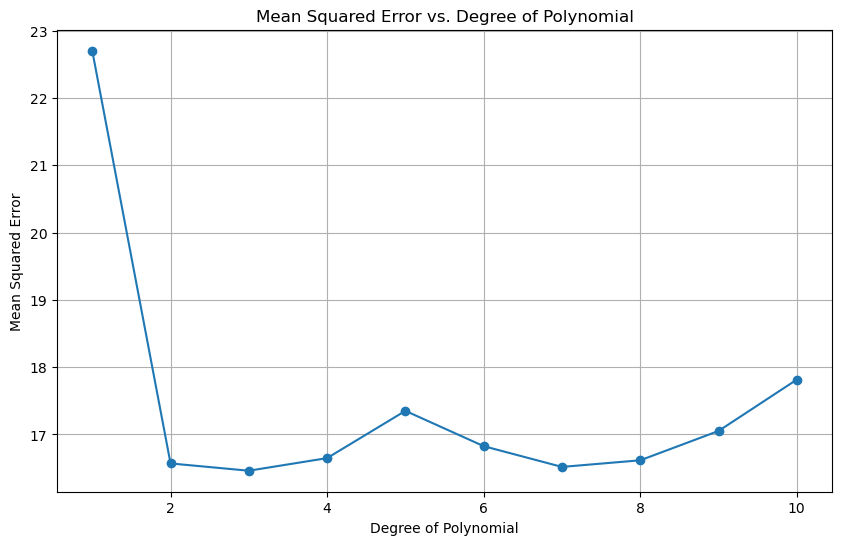

In [28]:
# Drop rows with missing values
auto_mpg = df.dropna()

# Define features and target
features = auto_mpg[['horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['mpg']

# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=4)

# List to store Mean Squared Errors
mse_list = []

for degree in degrees:
    # Add polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create a linear regression model
    model = LinearRegression()

    # Train the model on the polynomial features training data
    model.fit(X_train_poly, y_train)

    # Use the trained model to predict the target values in the test set
    y_pred = model.predict(X_test_poly)

    # Calculate the Mean Squared Error of the model on the test set
    mse = mean_squared_error(y_test, y_pred)

    # Store the Mean Squared Error in the list
    mse_list.append(mse)

# Plot the Mean Squared Error as a function of the degree of the polynomial
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_list, marker='o')
plt.title('Mean Squared Error vs. Degree of Polynomial')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()


We change the random state then varience increases 

## multiple train test split

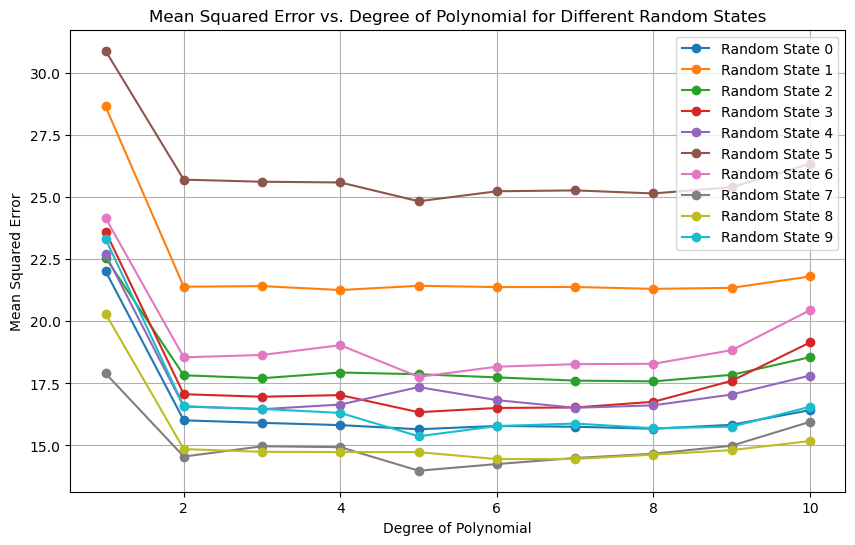

In [29]:


# Drop rows with missing values
auto_mpg = df.dropna()

# Define features and target
features = auto_mpg[['horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['mpg']

# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# List of random states
random_states = list(range(10))

# Create a plot
plt.figure(figsize=(10, 6))

for i, random_state in enumerate(random_states):
    # Split the dataset into a training set and a test set
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=random_state)

    # List to store Mean Squared Errors
    mse_list = []

    for degree in degrees:
        # Add polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Create a linear regression model
        model = LinearRegression()

        # Train the model on the polynomial features training data
        model.fit(X_train_poly, y_train)

        # Use the trained model to predict the target values in the test set
        y_pred = model.predict(X_test_poly)

        # Calculate the Mean Squared Error of the model on the test set
        mse = mean_squared_error(y_test, y_pred)

        # Store the Mean Squared Error in the list
        mse_list.append(mse)

    # Plot the Mean Squared Error as a function of the degree of the polynomial for the current random state
    plt.plot(degrees, mse_list, marker='o', label=f'Random State {random_state}')

plt.title('Mean Squared Error vs. Degree of Polynomial for Different Random States')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


Observe in if you change the random state then varience increases so much yadi varience dec hota tho sara score ek dursa ka upar overalap hota yaha bhut difference aa raha ha 

## k fold 

C:\Users\sumit\AppData\Local\Temp\ipykernel_7264\1783677333.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')


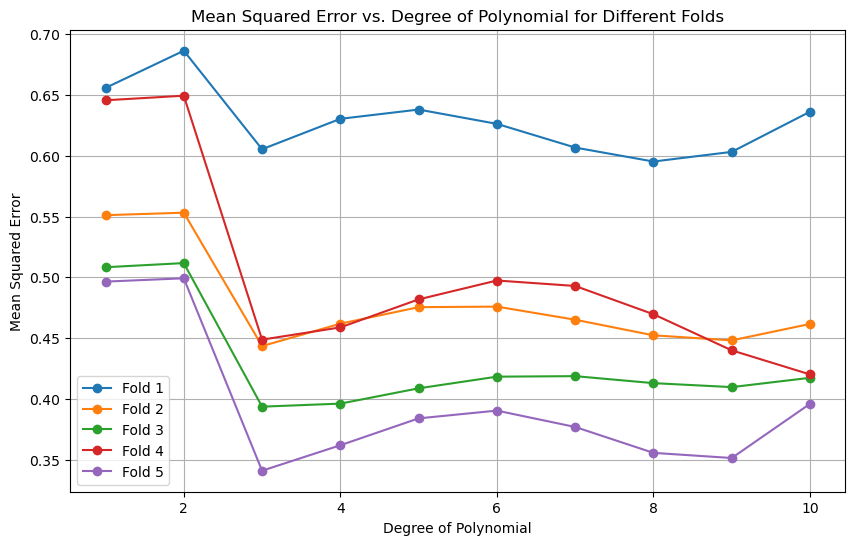

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Load the Auto MPG dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
auto_mpg = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')

# Drop rows with missing values
auto_mpg = auto_mpg.dropna()

# Define features and target
features = auto_mpg[['Horsepower']]  # Only use 'Horsepower' as a feature
target = auto_mpg['MPG']

# Convert to numpy arrays for easier manipulation
X = features.to_numpy()
y = target.to_numpy()

# List of polynomial degrees
degrees = list(range(1, 11))  # Extend degrees to 10

# Create a plot
plt.figure(figsize=(10, 6))

# Create a 5-fold cross validator
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # List to store Mean Squared Errors
    mse_list = []

    for degree in degrees:
        # Add polynomial features
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Create a linear regression model
        model = LinearRegression()

        # Train the model on the polynomial features training data
        model.fit(X_train_poly, y_train)

        # Use the trained model to predict the target values in the test set
        y_pred = model.predict(X_test_poly)

        # Calculate the Mean Squared Error of the model on the test set
        mse = mean_squared_error(y_test, y_pred)

        # Store the Mean Squared Error in the list
        mse_list.append(mse)

    # Plot the Mean Squared Error as a function of the degree of the polynomial for the current fold
    plt.plot(degrees, mse_list, marker='o', label=f'Fold {i + 1}')

plt.title('Mean Squared Error vs. Degree of Polynomial for Different Folds')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()


k fold ma varience bhut hi pass pass ha tho approx same raheta ha 

Cross-validation is performed only on the training data, never on the whole dataset.
To understand why this is a strict rule of data science, we must look at the first principles of a scientific trial.
------------------------------
## The Fundamental Separation of Roles
Before you do anything else in a machine learning project, you must split your data into two completely locked chambers:

   1. Development Data (Training Set): The sandbox where you experiment, build models, and tune settings.
   2. The Vault (Holdout Test Set): A pristine slice of data representing the future. It is locked away and never looked at until the project is completely finished.

       [ YOUR TOTAL ORIGINAL DATASET ]
                /           \
               /             \
 [ TRAINING DATA ]          [ HOLDOUT TEST DATA ]
        │                             │
  (Cross-Validation                   │ (Untouched until the very end 
   happens ONLY here)                 │  to give the final, honest grade)

------------------------------
## The Logic: Why CV is restricted to Training Data## 1. Preventing "Data Leakage" (Cheating)
Cross-validation is not just used to see how good a model is; it is primarily used to make decisions. You use CV to choose which algorithm to use (e.g., Random Forest vs. XGBoost) or to tune hyperparameters.
If you include the whole dataset in your cross-validation loop, the choices you make will be influenced by the test data. The test data will "leak" into your decision-making process. Your model will essentially look ahead at the exam questions while it is still studying.
## 2. The Illusion of Perfect Accuracy
If you run cross-validation on the whole dataset, you will get an incredibly optimistic validation score. However, when you deploy that model into production to read real-world data, its accuracy will plummet. Restricting cross-validation to the training split ensures that you have a completely untainted, independent holdout set to catch overfitting before your model goes live.
## 3. Simulating the Timeline of Reality
In the real world, your model is built today using past data, and it must predict tomorrow's future data.

* Training Data represents the past.
* Holdout Test Data simulates the future.

Cross-validation splits the training data over and over to simulate the transition from past to future. If you put the holdout test data inside the cross-validation loop, you are blending the past and the future together, breaking the timeline of reality.
------------------------------
## Summary of the Workflow

   1. Split your data immediately into Train (80%) and Test (20%).
   2. Lock the Test set away. Do not touch it.
   3. Run Cross-Validation on the 80% Train set to find your best model.
   4. Train your final chosen model on the entire 80% Train set.
   5. Test that final model once on the 20% Test set to get your true real-world accuracy score.

Would you like to explore what happens mathematically when data leaks into the test set, or see how to write a Python pipeline that automatically enforces this separation?



In [1]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load the Diabetes Dataset (Regression Task)
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# 2. Extract Holdout Test Set (The "Vault")
# This 20% is isolated immediately and NEVER enters the cross-validation loop.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Create a Pipeline to Prevent Data Leakage
# Scaling MUST happen inside each cross-validation fold, not on the whole dataset.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# 4. Set Up the K-Fold Object
# Shuffling is essential to ensure random, unbiased distribution among folds.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. Execute Cross-Validation ONLY on Training Data
# We use negative mean squared error because sklearn optimization maximizes scores.
cv_mse_scores = cross_val_score(
    pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error'
)
cv_r2_scores = cross_val_score(
    pipeline, X_train, y_train, cv=kf, scoring='r2'
)

# Convert negative MSE back to positive Root Mean Squared Error (RMSE)
cv_rmse_scores = np.sqrt(-cv_mse_scores)

print("--- CROSS-VALIDATION RESULTS (On Training Split Only) ---")
print(f"Mean CV R² Score: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std():.4f})")
print(f"Mean CV RMSE:     {cv_rmse_scores.mean():.2f} (+/- {cv_rmse_scores.std():.2f})")

# 6. Final Evaluation on Holdout Test Data
# Train the model on the full training partition
pipeline.fit(X_train, y_train)

# Test exactly once on the pristine test split
final_predictions = pipeline.predict(X_test)
final_r2 = r2_score(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print("\n--- FINAL HOLDOUT PERFORMANCE (Unseen Future Data) ---")
print(f"Final Test R² Score: {final_r2:.4f}")
print(f"Final Test RMSE:     {final_rmse:.2f}")


--- CROSS-VALIDATION RESULTS (On Training Split Only) ---
Mean CV R² Score: 0.4804 (+/- 0.0409)
Mean CV RMSE:     55.39 (+/- 2.36)

--- FINAL HOLDOUT PERFORMANCE (Unseen Future Data) ---
Final Test R² Score: 0.4526
Final Test RMSE:     53.85
